# All-NBA Team Prediction using Random Forest

Predicting which players make All-NBA teams (1st, 2nd, 3rd) using NBA player statistics from 2011-2025.

## 1. Data Loading & Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

In [2]:
# Load the master dataset with all features and player names
df_full = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')
print(f'Shape: {df_full.shape}')
df_full.head()

Shape: (5214, 60)


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,All_NBA_Label,All_NBA_Target,Season_End_Year,LEBRON,O-LEBRON,D-LEBRON,WAR
0,104.0,Arron Afflalo,25.0,DEN,SG,69.0,69.0,2324.0,312.0,627.0,0.498,105.0,248.0,0.423,207.0,379.0,0.546,0.581,138.0,163.0,0.847,45.0,206.0,251.0,168.0,34.0,31.0,71.0,153.0,867.0,0.0,NaN,afflaar01,13.6,0.620,0.396,0.260,2.3,9.9,6.2,10.9,0.7,1.0,9.2,14.8,4.8,1.4,6.2,0.128,1.7,-0.3,1.4,2.0,NaN,0,2011,0.44,1.01,-0.57,4.27
1,33.0,Ray Allen,35.0,BOS,SG,80.0,80.0,2890.0,480.0,978.0,0.491,168.0,378.0,0.444,312.0,600.0,0.520,0.577,193.0,219.0,0.881,51.0,223.0,274.0,219.0,77.0,16.0,117.0,147.0,1321.0,0.0,AS,allenra02,16.4,0.615,0.387,0.224,2.3,9.0,5.8,12.7,1.4,0.4,9.8,19.8,5.8,4.2,10.0,0.166,2.3,0.6,2.9,3.6,NaN,0,2011,1.02,0.61,0.41,6.45
2,165.0,Tony Allen,29.0,MEM,SG,72.0,31.0,1494.0,251.0,492.0,0.510,4.0,23.0,0.174,247.0,469.0,0.527,0.514,137.0,182.0,0.753,70.0,123.0,193.0,104.0,129.0,44.0,86.0,161.0,643.0,0.0,DPOY-46MOY-11DEF2,allento01,18.4,0.562,0.047,0.370,5.5,9.9,7.7,10.9,4.5,2.4,13.1,19.9,2.0,2.7,4.7,0.152,0.1,3.5,3.6,2.1,NaN,0,2011,1.72,-0.37,2.09,4.03
3,214.0,Al-Farouq Aminu,20.0,LAC,SF,81.0,14.0,1452.0,160.0,406.0,0.394,45.0,143.0,0.315,115.0,263.0,0.437,0.450,92.0,119.0,0.773,75.0,192.0,267.0,60.0,59.0,25.0,103.0,121.0,457.0,0.0,NaN,aminual01,9.6,0.499,0.352,0.293,6.1,15.4,10.8,6.4,2.1,1.3,18.3,17.3,-0.8,1.4,0.7,0.022,-2.7,-0.1,-2.8,-0.3,NaN,0,2011,-2.11,-2.35,0.23,0.17
4,310.0,Lou Amundson,28.0,GSW,PF,46.0,7.0,691.0,83.0,183.0,0.454,0.0,0.0,NaN,83.0,183.0,0.454,0.454,34.0,87.0,0.391,81.0,104.0,185.0,17.0,14.0,33.0,24.0,87.0,200.0,0.0,NaN,amundlo01,11.5,0.452,0.000,0.475,13.0,17.4,15.2,3.5,1.0,3.6,9.8,15.7,0.2,0.5,0.6,0.044,-3.1,-1.4,-4.5,-0.4,NaN,0,2011,-1.99,-2.16,0.16,0.14


In [3]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 5214 non-null   float64
 1   Player             5214 non-null   object 
 2   Age                5214 non-null   float64
 3   Team               5214 non-null   object 
 4   Pos                5214 non-null   object 
 5   G                  5214 non-null   float64
 6   GS                 5214 non-null   float64
 7   MP                 5214 non-null   float64
 8   FG                 5214 non-null   float64
 9   FGA                5214 non-null   float64
 10  FG%                5214 non-null   float64
 11  3P                 5214 non-null   float64
 12  3PA                5214 non-null   float64
 13  3P%                4961 non-null   float64
 14  2P                 5214 non-null   float64
 15  2PA                5214 non-null   float64
 16  2P%                5214 

In [4]:
df_full.describe()

,Rk,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,All_NBA_Target,Season_End_Year,LEBRON,O-LEBRON,D-LEBRON,WAR
count,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,4961.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5213.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000,5214.000000
mean,198.837745,26.376678,58.998274,30.313771,1429.742616,234.644802,509.613732,0.457465,60.550825,168.408707,0.316139,174.093978,341.205025,0.505459,0.516092,103.500575,134.245493,0.755146,61.707710,195.195627,256.903337,141.400077,45.452052,28.961834,80.543920,116.663790,633.341005,0.236287,14.095109,0.548710,0.333248,0.257770,4.992539,15.063886,10.022746,14.197104,1.569390,1.761316,12.750173,18.944572,1.598696,1.453951,3.053260,0.092168,-0.583007,-0.017453,-0.600940,0.757000,0.073648,2018.248370,-0.299595,-0.309073,0.009494,2.271523
std,117.145800,4.256098,17.776049,27.749201,704.123720,158.817098,334.607268,0.068067,57.895207,151.175907,0.117789,133.474782,254.438732,0.071372,0.059479,97.508511,120.437877,0.106525,56.880989,133.144629,180.641136,130.345611,29.571346,30.339929,57.234659,55.597975,439.845875,1.671398,4.443262,0.056341,0.214116,0.126921,3.778515,5.969431,4.529774,9.011315,0.597629,1.541764,3.936234,5.234946,1.971998,1.047388,2.720647,0.057723,2.407440,1.173586,2.768583,1.342948,0.409863,4.314674,1.725403,1.471475,1.110688,2.645281
min,1.000000,19.000000,7.000000,0.000000,204.000000,9.000000,22.000000,0.250000,0.000000,0.000000,0.000000,1.000000,10.000000,0.077000,0.286000,0.000000,0.000000,0.000000,0.000000,5.000000,9.000000,2.000000,0.000000,0.000000,3.000000,6.000000,33.000000,0.000000,1.000000,0.312000,0.000000,0.000000,0.000000,2.400000,2.300000,0.700000,0.000000,0.000000,2.200000,5.300000,-3.300000,-0.500000,-2.100000,-0.150000,-9.700000,-3.900000,-11.900000,-1.800000,0.000000,2011.000000,-4.890000,-4.360000,-3.545438,-3.006399
25%,98.000000,23.000000,48.000000,5.000000,835.000000,107.000000,239.000000,0.414000,12.000000,42.000000,0.294000,70.000000,141.000000,0.459000,0.478000,36.000000,49.000000,0.698000,23.000000,98.000000,126.000000,51.000000,23.000000,9.000000,38.000000,73.000000,285.000000,0.000000,11.000000,0.513000,0.167000,0.168000,2.100000,10.400000,6.400000,7.500000,1.100000,0.700000,10.100000,15.100000,0.300000,0.700000,1.100000,0.055000,-2.175000,-0.800000,-2.400000,-0.100000,0.000000,2015.000000,-1.464005,-1.265805,-0.739507,0.431061
50%,196.000000,26.000000,63.000000,20.500000,1411.500000,201.000000,442.000000,0.447000,46.000000,135.000000,0.343000,138.000000,274.000000,0.500000,0.514000,73.000000,98.000000,0.771000,43.000000,167.000000,216.000000,99.000000,40.000000,19.000000,66.000000,114.000000,537.000000,0.000000,13.550000,0.549000,0.350000,0.238000,3.600000,13.800000,8.800000,11.300000,1.500000,1.300000,12.300000,18.200000,1.100000,1.200000,2.400000,0.091000,-0.800000,-0.100000,-0.800000,0.400000,0.000000,2018.000000,-0.529662,-0.510000,-0.045683,1.399825
75%,295.750000,29.000000,73.000000,57.000000,1999.000000,328.000000,712.000000,0.490000,93.000000,258.000000,0.378000,243.000000,477.000000,0.548000,0.553000,139.000000,181.750000,0.830000,80.000000,256.000000,335.000000,187.000000,62.000000,38.000000,108.000000,155.000000,874.750000,0.000000,16.675000,0.584000,0.486000,0.322000,7.200000,18.800000,12.900000,18.700000,1.900000,2.400000,14.900000,22.200000,2.400000,2.000000,4.300000,0.127

## 2. Target Variable Analysis

In [5]:
# Target distribution (0=None, 1=NBA 3rd Team, 2=NBA 2nd Team, 3=NBA 1st Team)
print('All_NBA_Target value counts:')
print(df_full['All_NBA_Target'].value_counts().sort_index())
print()
print('All_NBA_Label value counts:')
print(df_full['All_NBA_Label'].value_counts())

All_NBA_Target value counts:
All_NBA_Target
0    5025
1      59
2      65
3      65
Name: count, dtype: int64

All_NBA_Label value counts:
All_NBA_Label
NBA1    65
NBA2    65
NBA3    59
Name: count, dtype: int64


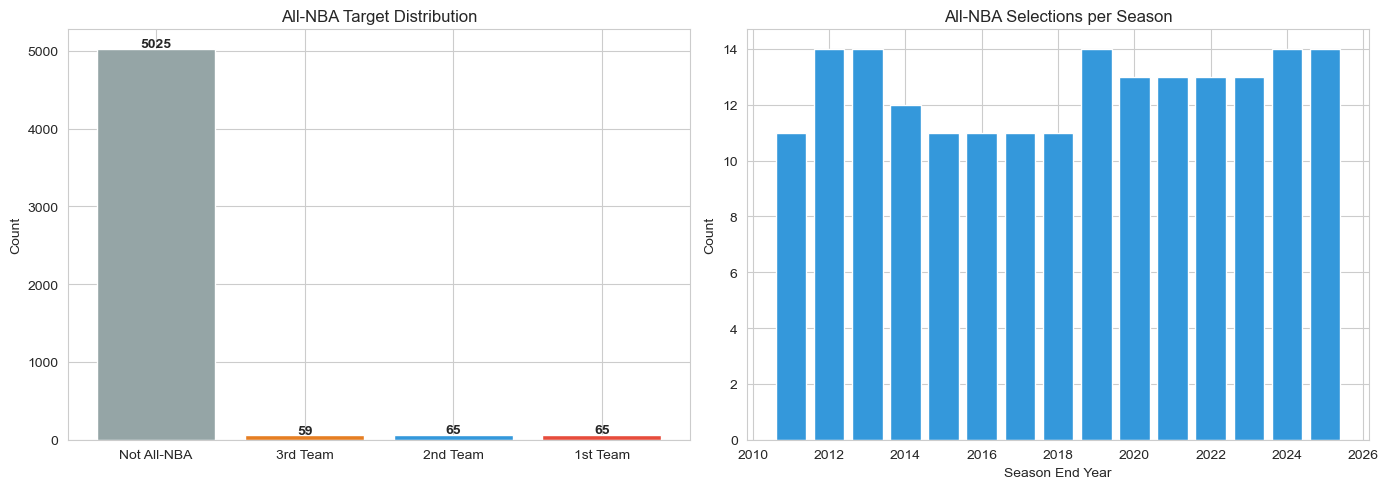

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of target distribution
target_counts = df_full['All_NBA_Target'].value_counts().sort_index()
labels = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team']
colors = ['#95a5a6', '#e67e22', '#3498db', '#e74c3c']
axes[0].bar(labels, target_counts.values, color=colors)
axes[0].set_title('All-NBA Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# All-NBA selections by year
allnba_by_year = df_full[df_full['All_NBA_Target'] > 0].groupby('Season_End_Year')['All_NBA_Target'].count()
axes[1].bar(allnba_by_year.index, allnba_by_year.values, color='#3498db')
axes[1].set_title('All-NBA Selections per Season')
axes[1].set_xlabel('Season End Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Feature Exploration

In [7]:
# Missing values
missing = df_full.isnull().sum()
missing_pct = (missing / len(df_full) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

               Missing Count  Missing %
3P%                      253       4.85
FT%                        1       0.02
Awards                  4436      85.08
All_NBA_Label           5025      96.38


In [8]:
# Compare key stats: All-NBA vs Non All-NBA players
key_stats = ['PTS', 'TRB', 'AST', 'STL', 'BLK', 'PER', 'WS', 'BPM', 'VORP', 'LEBRON', 'WAR', 'MP', 'G']
comparison = df_full.groupby('All_NBA_Target')[key_stats].mean().round(2)
comparison.index = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team'][:len(comparison)]
comparison.T

,Not All-NBA,3rd Team,2nd Team,1st Team
PTS,592.79,1514.68,1670.88,1930.42
TRB,246.07,530.97,517.02,585.46
AST,131.61,376.25,389.80,436.78
STL,43.70,91.73,82.48,102.09
BLK,27.88,52.83,55.86,63.80
PER,13.71,21.73,23.94,26.96
WS,2.77,8.96,10.12,12.24
BPM,-0.85,4.31,5.58,8.12
VORP,0.60,3.92,4.67,6.42
LEBRON,-0.46,3.06,3.57,5.10


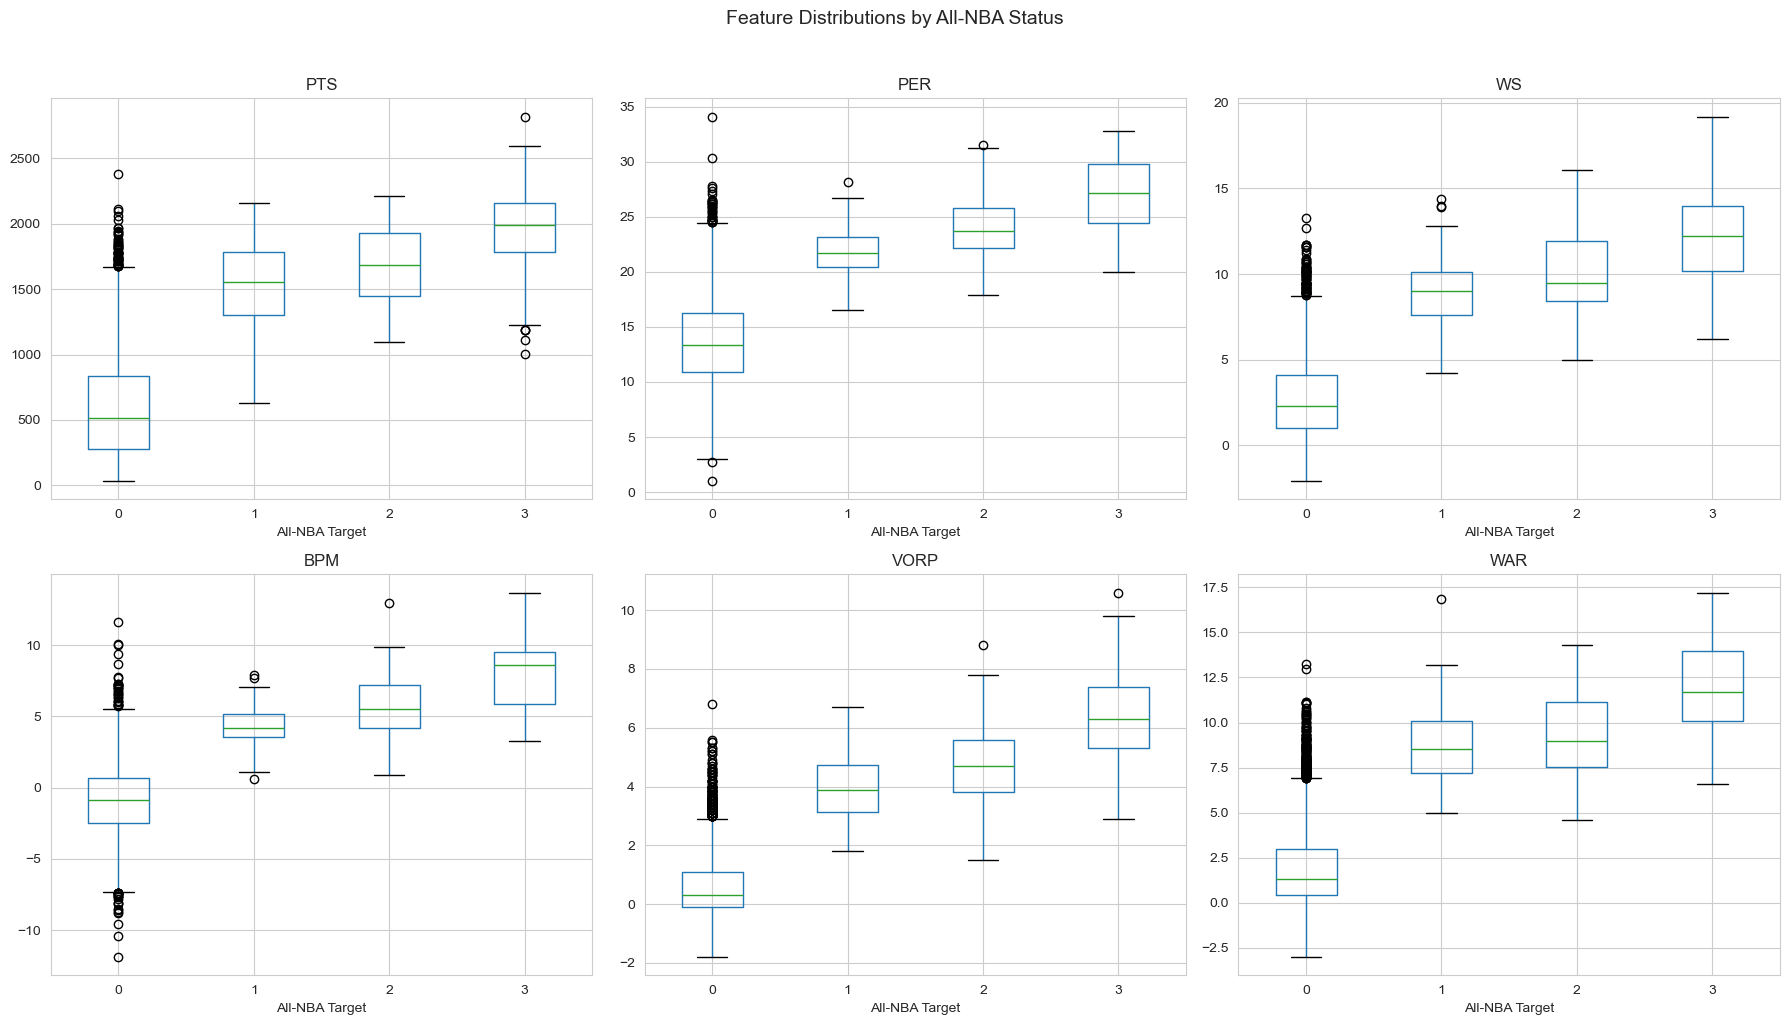

In [9]:
# Box plots of key features by All-NBA status
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_features = ['PTS', 'PER', 'WS', 'BPM', 'VORP', 'WAR']

for ax, feat in zip(axes.ravel(), plot_features):
    df_full.boxplot(column=feat, by='All_NBA_Target', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('All-NBA Target')

plt.suptitle('Feature Distributions by All-NBA Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

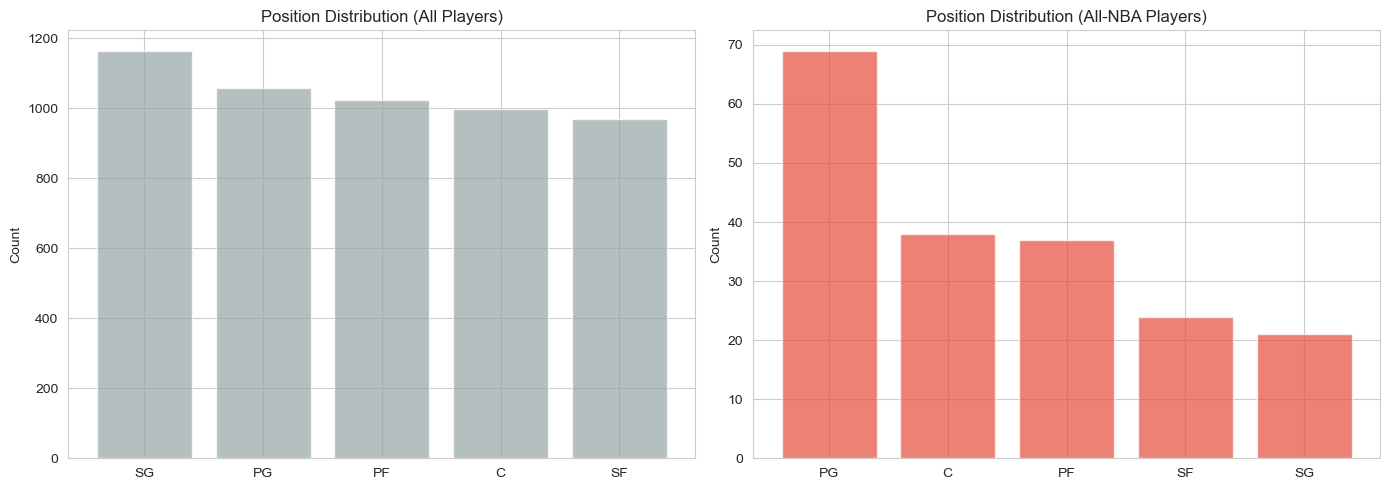

In [10]:
# Position distribution among All-NBA selections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_allnba = df_full[df_full['All_NBA_Target'] > 0]['Pos'].value_counts()
pos_all = df_full['Pos'].value_counts()

axes[0].bar(pos_all.index, pos_all.values, color='#95a5a6', alpha=0.7)
axes[0].set_title('Position Distribution (All Players)')
axes[0].set_ylabel('Count')

axes[1].bar(pos_allnba.index, pos_allnba.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Position Distribution (All-NBA Players)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

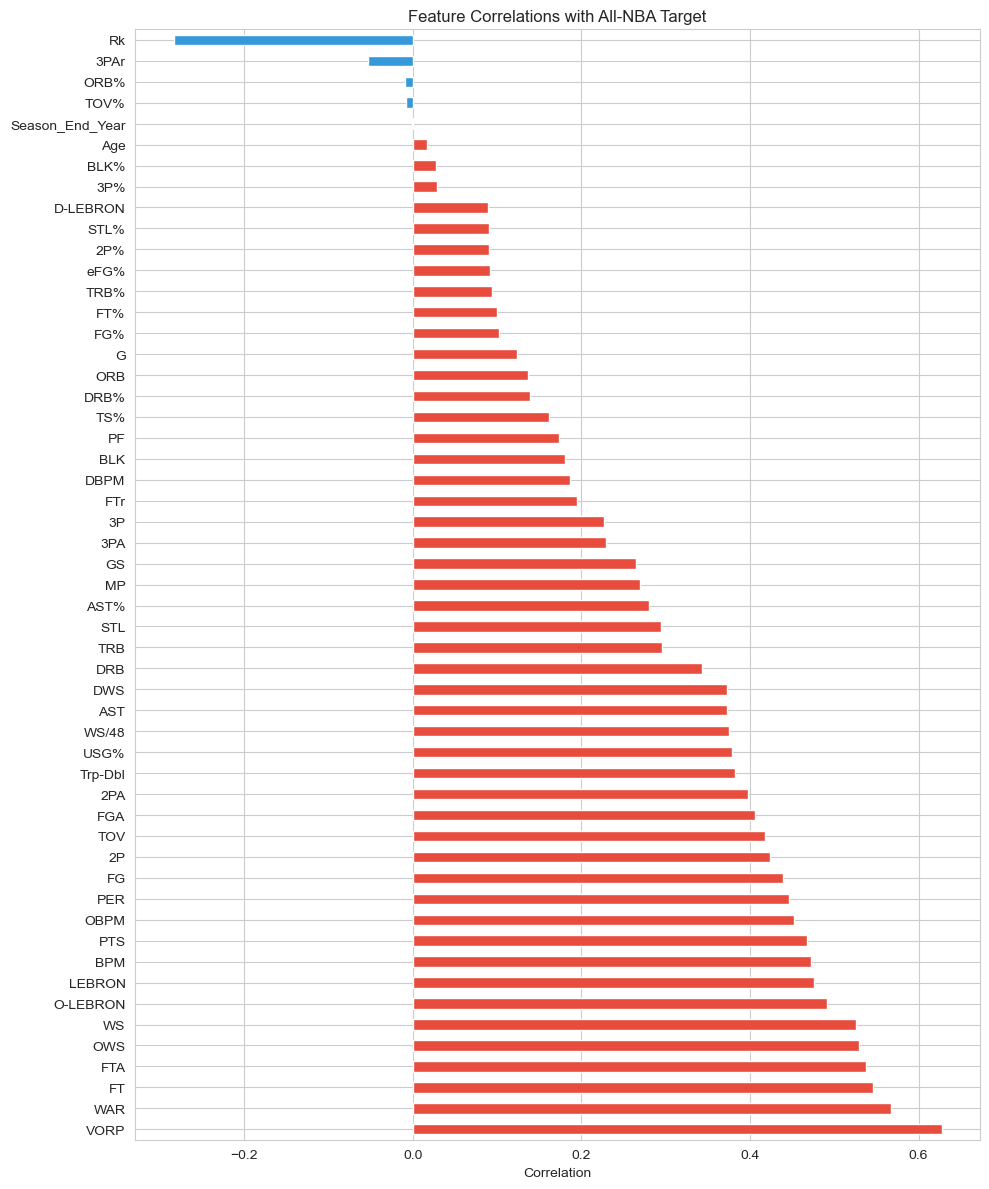

In [11]:
# Correlation heatmap of numeric features with target
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
correlations = df_full[numeric_cols].corr()['All_NBA_Target'].drop('All_NBA_Target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
correlations.plot(kind='barh', ax=ax, color=correlations.apply(lambda x: '#e74c3c' if x > 0 else '#3498db'))
ax.set_title('Feature Correlations with All-NBA Target')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

## 4. Data Preparation for Modeling

In [12]:
# Load the hybrid trimmed dataset (balanced mix of basic + advanced + impact features)
df = pd.read_csv('data/model_datasets/hybrid_trimmed_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (5214, 28)
Columns: ['Age', 'Pos', 'G', 'GS', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'eFG%', 'TS%', 'PER', 'USG%', 'WS', 'WS/48', 'BPM', 'VORP', 'LEBRON', 'O-LEBRON', 'D-LEBRON', 'WAR', 'Season_End_Year', 'All_NBA_Target']


,Age,Pos,G,GS,MP,PTS,TRB,AST,STL,BLK,TOV,FG%,3P%,FT%,eFG%,TS%,PER,USG%,WS,WS/48,BPM,VORP,LEBRON,O-LEBRON,D-LEBRON,WAR,Season_End_Year,All_NBA_Target
0,25.0,SG,69.0,69.0,2324.0,867.0,251.0,168.0,34.0,31.0,71.0,0.498,0.423,0.847,0.581,0.620,13.6,14.8,6.2,0.128,1.4,2.0,0.44,1.01,-0.57,4.27,2011,0
1,35.0,SG,80.0,80.0,2890.0,1321.0,274.0,219.0,77.0,16.0,117.0,0.491,0.444,0.881,0.577,0.615,16.4,19.8,10.0,0.166,2.9,3.6,1.02,0.61,0.41,6.45,2011,0
2,29.0,SG,72.0,31.0,1494.0,643.0,193.0,104.0,129.0,44.0,86.0,0.510,0.174,0.753,0.514,0.562,18.4,19.9,4.7,0.152,3.6,2.1,1.72,-0.37,2.09,4.03,2011,0
3,20.0,SF,81.0,14.0,1452.0,457.0,267.0,60.0,59.0,25.0,103.0,0.394,0.315,0.773,0.450,0.499,9.6,17.3,0.7,0.022,-2.8,-0.3,-2.11,-2.35,0.23,0.17,2011,0
4,28.0,PF,46.0,7.0,691.0,200.0,185.0,17.0,14.0,33.0,24.0,0.454,NaN,0.391,0.454,0.452,11.5,15.7,0.6,0.044,-4.5,-0.4,-1.99,-2.16,0.16,0.14,2011,0


In [13]:
# Encode the position column
le_pos = LabelEncoder()
df['Pos_encoded'] = le_pos.fit_transform(df['Pos'].astype(str))
print('Position encoding:', dict(zip(le_pos.classes_, le_pos.transform(le_pos.classes_))))

# Define features and target
drop_cols = ['Pos', 'All_NBA_Target']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['All_NBA_Target'].copy()

# Handle missing values - fill with 0 (e.g., 3P% for players with 0 attempts)
print(f'\nMissing values before fill:\n{X.isnull().sum()[X.isnull().sum() > 0]}')
X = X.fillna(0)

print(f'\nFeatures ({len(feature_cols)}): {feature_cols}')
print(f'Target distribution:\n{y.value_counts().sort_index()}')

Position encoding: {'C': 0, 'PF': 1, 'PG': 2, 'SF': 3, 'SG': 4}

Missing values before fill:
3P%    253
FT%      1
dtype: int64

Features (27): ['Age', 'G', 'GS', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'eFG%', 'TS%', 'PER', 'USG%', 'WS', 'WS/48', 'BPM', 'VORP', 'LEBRON', 'O-LEBRON', 'D-LEBRON', 'WAR', 'Season_End_Year', 'Pos_encoded']
Target distribution:
All_NBA_Target
0    5025
1      59
2      65
3      65
Name: count, dtype: int64


In [14]:
# Train/test split - use Season_End_Year for temporal split
# Train on 2011-2022, test on 2023-2025 (more realistic evaluation)
train_mask = X['Season_End_Year'] <= 2022
test_mask = X['Season_End_Year'] > 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Train set: {X_train.shape[0]} samples ({y_train.value_counts().sort_index().to_dict()})')
print(f'Test set:  {X_test.shape[0]} samples ({y_test.value_counts().sort_index().to_dict()})')

Train set: 4094 samples ({0: 3946, 1: 46, 2: 52, 3: 50})
Test set:  1120 samples ({0: 1079, 1: 13, 2: 13, 3: 15})


## 5. Random Forest Model

In [15]:
# Train Random Forest with class_weight='balanced' to handle imbalance
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Training complete.')
print(f'Train accuracy: {rf.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {rf.score(X_test, y_test):.4f}')

Training complete.
Train accuracy: 0.9910
Test accuracy:  0.9759


In [16]:
# Classification report
y_pred = rf.predict(X_test)
target_names = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team']
# Only include labels that exist in test set
present_labels = sorted(y_test.unique())
present_names = [target_names[i] for i in present_labels]

print(classification_report(y_test, y_pred, labels=present_labels, target_names=present_names))

              precision    recall  f1-score   support

 Not All-NBA       1.00      0.99      0.99      1079
    3rd Team       0.40      0.46      0.43        13
    2nd Team       0.29      0.38      0.33        13
    1st Team       0.93      0.87      0.90        15

    accuracy                           0.98      1120
   macro avg       0.65      0.68      0.66      1120
weighted avg       0.98      0.98      0.98      1120



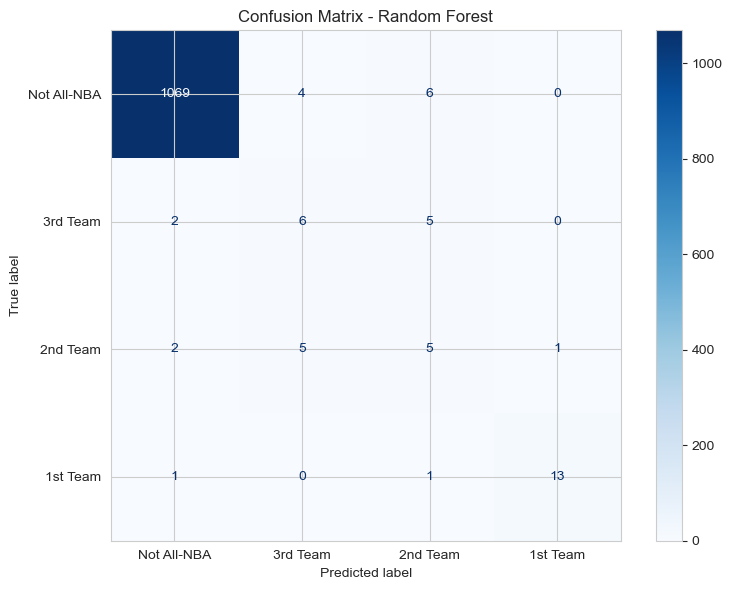

In [17]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

## 6. Feature Importance

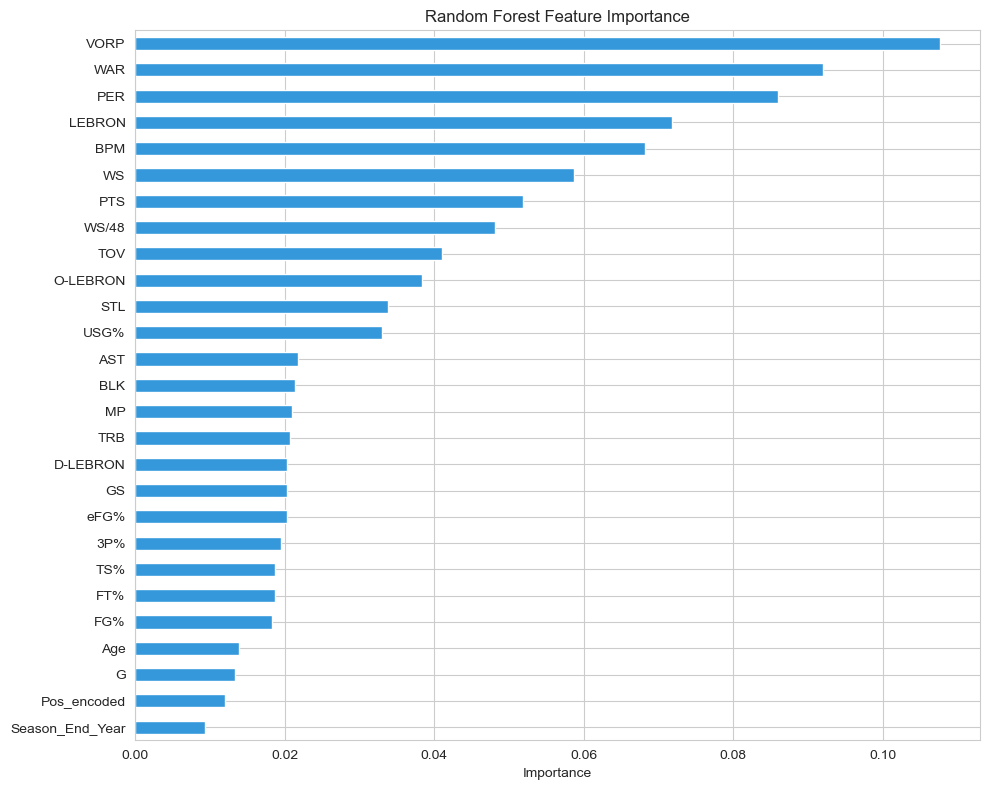

In [18]:
# Feature importance
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Cross-Validation

In [19]:
# Stratified K-Fold cross-validation on the full dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')
print(f'Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Individual fold scores: {cv_scores.round(4)}')

Cross-validation accuracy: 0.9697 (+/- 0.0043)
Individual fold scores: [0.9684 0.9645 0.9732 0.976  0.9664]


## 8. Predictions - Who Would Make All-NBA?

In [20]:
# Load full dataset with player names to see who the model predicts
df_names = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')

# Get test set predictions with player names
test_players = df_names[df_names['Season_End_Year'] > 2022][['Player', 'Team', 'Pos', 'Season_End_Year', 'All_NBA_Label', 'All_NBA_Target']].reset_index(drop=True)
test_players['Predicted'] = y_pred
test_players['Predicted_Label'] = test_players['Predicted'].map({0: 'None', 1: 'NBA3', 2: 'NBA2', 3: 'NBA1'})

# Show predicted All-NBA players
predicted_allnba = test_players[test_players['Predicted'] > 0].sort_values(['Season_End_Year', 'Predicted'], ascending=[True, False])
print(f'Predicted All-NBA selections ({len(predicted_allnba)} players):')
predicted_allnba

Predicted All-NBA selections (46 players):


,Player,Team,Pos,Season_End_Year,All_NBA_Label,All_NBA_Target,Predicted,Predicted_Label
10,Giannis Antetokounmpo,MIL,PF,2023,NBA1,3,3,NBA1
82,Luka Dončić,DAL,PG,2023,NBA1,3,3,NBA1
94,Joel Embiid,PHI,C,2023,NBA1,3,3,NBA1
112,Shai Gilgeous-Alexander,OKC,PG,2023,NBA1,3,3,NBA1
172,Nikola Jokić,DEN,C,2023,NBA2,2,3,NBA1
311,Jayson Tatum,BOS,SF,2023,NBA1,3,3,NBA1
72,Stephen Curry,GSW,PG,2023,NBA2,2,2,NBA2
74,Anthony Davis,LAL,C,2023,NaN,0,2,NBA2
128,Tyrese Haliburton,IND,PG,2023,NaN,0,2,NBA2
131,James Harden,PHI,PG,2023,NaN,0,2,NBA2


In [21]:
# Compare predictions vs actual for test years
for year in sorted(test_players['Season_End_Year'].unique()):
    year_data = test_players[test_players['Season_End_Year'] == year]
    print(f'\n{"=" * 50}')
    print(f'Season {year}')
    print(f'{"=" * 50}')
    
    actual = year_data[year_data['All_NBA_Target'] > 0][['Player', 'Team', 'Pos', 'All_NBA_Label']]
    predicted = year_data[year_data['Predicted'] > 0][['Player', 'Team', 'Pos', 'Predicted_Label']]
    
    print(f'\nActual All-NBA ({len(actual)}):')
    if len(actual) > 0:
        print(actual.to_string(index=False))
    else:
        print('  (no data)')
    
    print(f'\nPredicted All-NBA ({len(predicted)}):')
    if len(predicted) > 0:
        print(predicted.to_string(index=False))
    else:
        print('  (none predicted)')


Season 2023

Actual All-NBA (13):
                 Player Team Pos All_NBA_Label
  Giannis Antetokounmpo  MIL  PF          NBA1
           Jaylen Brown  BOS  SF          NBA2
          Stephen Curry  GSW  PG          NBA2
            Luka Dončić  DAL  PG          NBA1
            Joel Embiid  PHI   C          NBA1
           De'Aaron Fox  SAC  PG          NBA3
Shai Gilgeous-Alexander  OKC  PG          NBA1
           Nikola Jokić  DEN   C          NBA2
         Damian Lillard  POR  PG          NBA3
       Donovan Mitchell  CLE  SG          NBA2
          Julius Randle  NYK  PF          NBA3
       Domantas Sabonis  SAC   C          NBA3
           Jayson Tatum  BOS  SF          NBA1

Predicted All-NBA (18):
                 Player Team Pos Predicted_Label
  Giannis Antetokounmpo  MIL  PF            NBA1
          Stephen Curry  GSW  PG            NBA2
          Anthony Davis  LAL   C            NBA2
            Luka Dončić  DAL  PG            NBA1
            Joel Embiid  PHI   C     

## 9. Binary Classification: All-NBA or Not

The multiclass model above struggles to distinguish between 1st/2nd/3rd team (only ~60 samples each, and the distinction is subjective voting margins). A binary model — **All-NBA vs Not** — is a more robust formulation.

**Issues addressed from the multiclass model:**
- **Misleading accuracy**: 96.4% baseline by predicting all 0s. We now focus on F1, precision-recall curves.
- **Missing value handling**: Use median instead of 0 for `3P%` (0 implies 0% shooter, not "no attempts").
- **Better evaluation**: Precision-recall curve, probability calibration, and per-year breakdown.

In [22]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, PrecisionRecallDisplay
)

# Reload and prepare data
df_bin = pd.read_csv('data/model_datasets/hybrid_trimmed_dataset.csv')

# Binary target: 1 if any All-NBA team, 0 otherwise
df_bin['All_NBA_Binary'] = (df_bin['All_NBA_Target'] > 0).astype(int)

print('Binary target distribution:')
print(df_bin['All_NBA_Binary'].value_counts())
print(f'\nPositive rate: {df_bin["All_NBA_Binary"].mean():.3%}')

Binary target distribution:
All_NBA_Binary
0    5025
1     189
Name: count, dtype: int64

Positive rate: 3.625%


In [23]:
# Encode position
le_pos_bin = LabelEncoder()
df_bin['Pos_encoded'] = le_pos_bin.fit_transform(df_bin['Pos'].astype(str))

# Features - drop original target, label, and string Pos
drop_cols_bin = ['Pos', 'All_NBA_Target', 'All_NBA_Binary']
feature_cols_bin = [c for c in df_bin.columns if c not in drop_cols_bin]

X_bin = df_bin[feature_cols_bin].copy()
y_bin = df_bin['All_NBA_Binary'].copy()

# Better missing value handling: median fill instead of 0
for col in X_bin.columns:
    if X_bin[col].isnull().any():
        median_val = X_bin[col].median()
        print(f'Filling {col} NaN ({X_bin[col].isnull().sum()} values) with median={median_val:.3f}')
        X_bin[col] = X_bin[col].fillna(median_val)

# Temporal split: train 2011-2022, test 2023-2025
train_mask_bin = X_bin['Season_End_Year'] <= 2022
test_mask_bin = X_bin['Season_End_Year'] > 2022

X_train_bin, X_test_bin = X_bin[train_mask_bin], X_bin[test_mask_bin]
y_train_bin, y_test_bin = y_bin[train_mask_bin], y_bin[test_mask_bin]

print(f'\nTrain: {X_train_bin.shape[0]} ({y_train_bin.sum()} positives, {y_train_bin.mean():.2%})')
print(f'Test:  {X_test_bin.shape[0]} ({y_test_bin.sum()} positives, {y_test_bin.mean():.2%})')
print(f'\nBaseline accuracy (predict all 0): {1 - y_test_bin.mean():.3%}')

Filling 3P% NaN (253 values) with median=0.343
Filling FT% NaN (1 values) with median=0.771

Train: 4094 (148 positives, 3.62%)
Test:  1120 (41 positives, 3.66%)

Baseline accuracy (predict all 0): 96.339%


In [24]:
# Train binary Random Forest
rf_bin = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train_bin, y_train_bin)

y_pred_bin = rf_bin.predict(X_test_bin)
y_proba_bin = rf_bin.predict_proba(X_test_bin)[:, 1]

print('Binary Random Forest Results')
print('=' * 50)
print(f'Test accuracy:  {rf_bin.score(X_test_bin, y_test_bin):.4f}')
print(f'Baseline (all 0): {1 - y_test_bin.mean():.4f}')
print(f'\nF1 Score: {f1_score(y_test_bin, y_pred_bin):.4f}')
print(f'Average Precision (PR-AUC): {average_precision_score(y_test_bin, y_proba_bin):.4f}')
print()
print(classification_report(y_test_bin, y_pred_bin, target_names=['Not All-NBA', 'All-NBA']))

Binary Random Forest Results
Test accuracy:  0.9848
Baseline (all 0): 0.9634

F1 Score: 0.8132
Average Precision (PR-AUC): 0.9203

              precision    recall  f1-score   support

 Not All-NBA       1.00      0.99      0.99      1079
     All-NBA       0.74      0.90      0.81        41

    accuracy                           0.98      1120
   macro avg       0.87      0.95      0.90      1120
weighted avg       0.99      0.98      0.99      1120



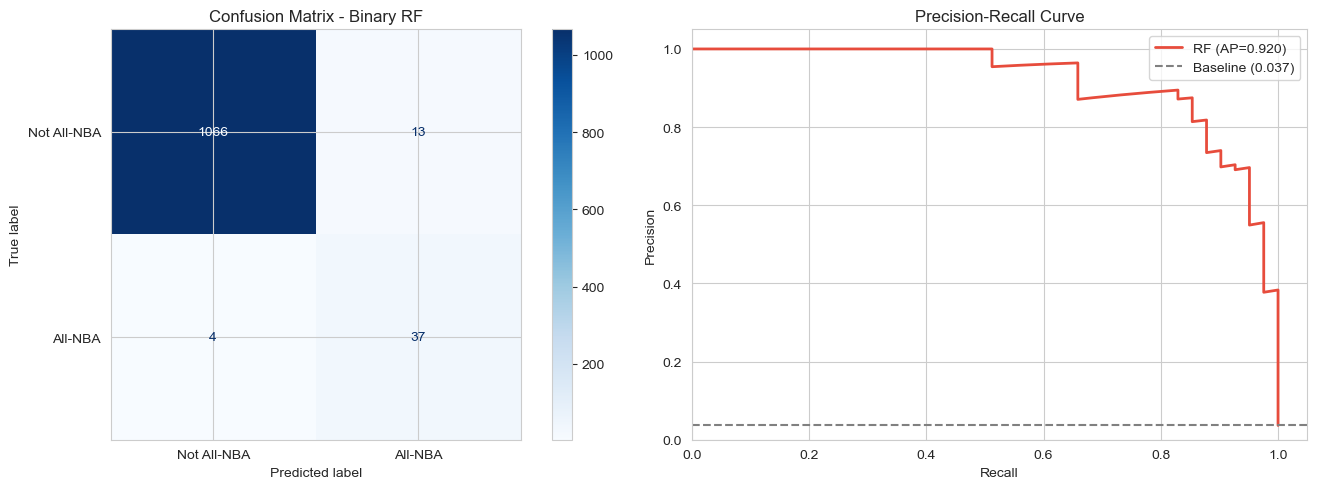

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
ConfusionMatrixDisplay(cm_bin, display_labels=['Not All-NBA', 'All-NBA']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Binary RF')

# Precision-Recall curve (much more informative than ROC for imbalanced data)
precision, recall, thresholds = precision_recall_curve(y_test_bin, y_proba_bin)
ap = average_precision_score(y_test_bin, y_proba_bin)
axes[1].plot(recall, precision, color='#e74c3c', lw=2, label=f'RF (AP={ap:.3f})')
axes[1].axhline(y=y_test_bin.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test_bin.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].set_xlim([0, 1.05])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

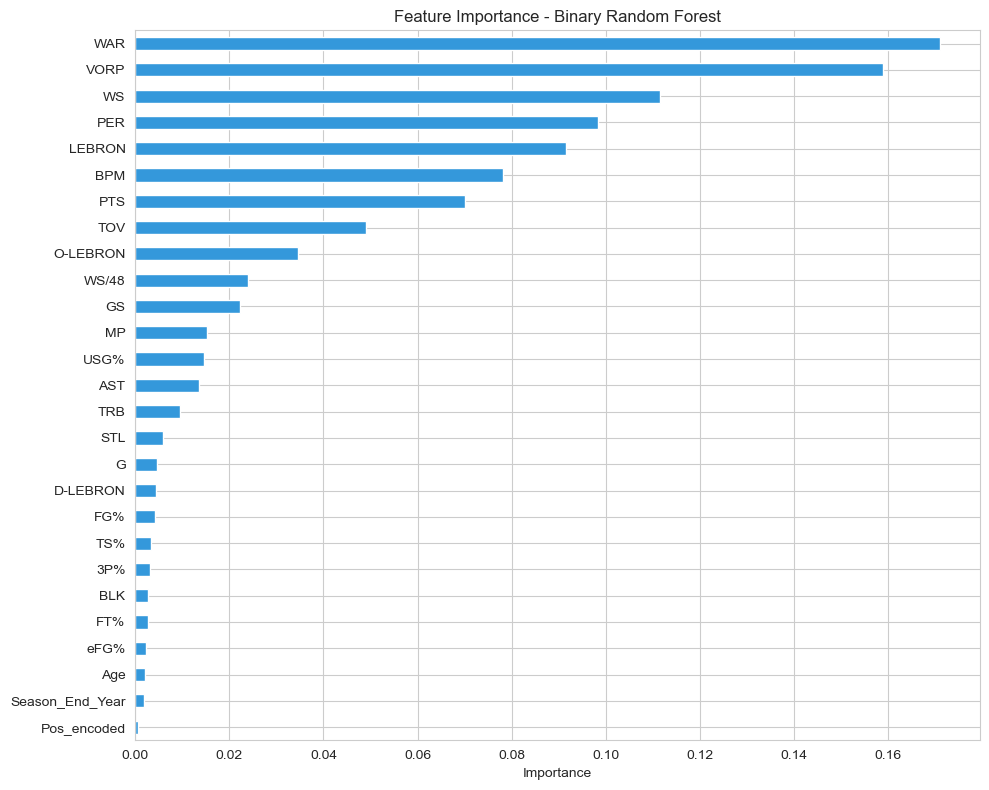

In [26]:
# Feature importance for binary model
importance_bin = pd.Series(rf_bin.feature_importances_, index=feature_cols_bin).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance_bin.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Feature Importance - Binary Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [27]:
# Cross-validation with F1 scoring (more meaningful than accuracy for imbalanced data)
skf_bin = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(rf_bin, X_bin, y_bin, cv=skf_bin, scoring='accuracy')
cv_f1 = cross_val_score(rf_bin, X_bin, y_bin, cv=skf_bin, scoring='f1')
cv_ap = cross_val_score(rf_bin, X_bin, y_bin, cv=skf_bin, scoring='average_precision')

print('5-Fold Cross-Validation Results')
print('=' * 50)
print(f'Accuracy:          {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})')
print(f'F1 Score:          {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})')
print(f'Avg Precision (AP): {cv_ap.mean():.4f} (+/- {cv_ap.std():.4f})')

5-Fold Cross-Validation Results
Accuracy:          0.9801 (+/- 0.0031)
F1 Score:          0.7393 (+/- 0.0448)
Avg Precision (AP): 0.8369 (+/- 0.0553)


In [28]:
# Per-year predictions with player names and probability scores
df_names = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')
test_players_bin = df_names[df_names['Season_End_Year'] > 2022][['Player', 'Team', 'Pos', 'Season_End_Year', 'All_NBA_Label', 'All_NBA_Target']].reset_index(drop=True)
test_players_bin['Actual'] = (test_players_bin['All_NBA_Target'] > 0).astype(int)
test_players_bin['Predicted'] = y_pred_bin
test_players_bin['Probability'] = y_proba_bin

for year in sorted(test_players_bin['Season_End_Year'].unique()):
    year_data = test_players_bin[test_players_bin['Season_End_Year'] == year].copy()
    
    print(f'\n{"=" * 60}')
    print(f'Season {year}')
    print(f'{"=" * 60}')
    
    # Show top 20 by probability
    top = year_data.nlargest(20, 'Probability')[['Player', 'Team', 'Pos', 'Actual', 'Predicted', 'Probability', 'All_NBA_Label']]
    top['Probability'] = top['Probability'].round(3)
    top['Correct'] = (top['Actual'] == top['Predicted']).map({True: 'Y', False: ''})
    print(top.to_string(index=False))
    
    # Summary stats
    actual_pos = year_data['Actual'].sum()
    pred_pos = year_data['Predicted'].sum()
    correct = ((year_data['Actual'] == 1) & (year_data['Predicted'] == 1)).sum()
    print(f'\nActual: {actual_pos} | Predicted: {pred_pos} | Correct: {correct}/{actual_pos}')


Season 2023
                 Player Team Pos  Actual  Predicted  Probability All_NBA_Label Correct
Shai Gilgeous-Alexander  OKC  PG       1          1        0.992          NBA1       Y
            Joel Embiid  PHI   C       1          1        0.991          NBA1       Y
            Luka Dončić  DAL  PG       1          1        0.990          NBA1       Y
           Jayson Tatum  BOS  SF       1          1        0.989          NBA1       Y
       Donovan Mitchell  CLE  SG       1          1        0.976          NBA2       Y
  Giannis Antetokounmpo  MIL  PF       1          1        0.964          NBA1       Y
           Nikola Jokić  DEN   C       1          1        0.956          NBA2       Y
         Damian Lillard  POR  PG       1          1        0.948          NBA3       Y
          Stephen Curry  GSW  PG       1          1        0.946          NBA2       Y
       Domantas Sabonis  SAC   C       1          1        0.882          NBA3       Y
          Anthony Davis  LAL  